# Expectation Decider

## Mathematics & Advanced Statistics

### Project Objective

The objective of this project is to analyze the probability of students passing a competitive mathematics examination using historical student data. Various probability concepts such as empirical probability, theoretical probability, probability distributions, contingency tables, conditional probability, and Bayes' Theorem are applied to understand how factors like study hours, attendance, group discussions, and previous test scores affect the probability of passing the final examination.

---

## Dataset Description

The dataset contains information for **200 students** with the following attributes:

| Column | Description |
|---------|-------------|
| study_hours | Number of hours studied per week |
| attendance | Attendance percentage |
| group_discussion | Participation in group discussions (Yes/No) |
| previous_test_score | Previous internal examination marks |
| final_exam_pass | Pass/Fail status |

---

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

## Load Dataset

In [3]:
df = pd.read_csv("Expectation_Decider_Dataset.csv")
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,12,67,Yes,87,Pass
1,6,75,Yes,48,Fail
2,13,66,Yes,77,Pass
3,8,62,Yes,45,Fail
4,5,74,Yes,75,Fail


# 1. Understanding the Basics

## A. What is Probability?

Probability is a branch of mathematics that measures the likelihood of an event occurring. It is expressed as a value between **0 and 1**.

- **Probability = 0** → Impossible event
- **Probability = 1** → Certain event

### Formula

**P(E)= Number of Favorable Outcomes / Total Number of Outcomes**


Where,

- **P(E)** = Probability of an event
- **Favorable Outcomes** = Number of times the event occurs
- **Total Outcomes** = Total number of observations

## B. Key Probability Terminology

### Experiment
An activity that produces one or more outcomes.

**Example:** Selecting one student from the dataset.

---

### Outcome
A possible result of an experiment.

**Example:** The selected student passes the final exam.

---

### Sample Space (S)
The set of all possible outcomes.

**Example:** {Pass, Fail}

---

### Event
A specific outcome or a group of outcomes.

**Example:** Student attended more than 80%.

---

### Independent Events
Two events are independent if one event does not affect the probability of the other.

---

### Dependent Events
Two events are dependent if one event affects the probability of the other.

---

### Conditional Probability
The probability of an event occurring given that another event has already occurred.

**P(A | B) = P(A ∩ B) / P(B)**

## C. Three Probability Event Examples from the Dataset

### Event 1
A student studies more than **10 hours per week**.

### Event 2
A student has **attendance greater than 80%**.

### Event 3
A student participates in **group discussions and passes the final examination**.

# 2. Types of Probability

There are two important types of probability used in this project:

## A. Theoretical Probability

Theoretical probability is calculated using mathematical reasoning without conducting an experiment.

### Formula

**P(E) = Favorable Outcomes / Total Possible Outcomes**

---

## B. Empirical Probability

Empirical probability is calculated using actual observed data.

### Formula

**P(E) = Number of times event occurs / Total observations**

In [4]:
total_students = len(df)
pass_students = (df["final_exam_pass"] == "Pass").sum()

empirical_probability = pass_students / total_students

print("Total Students :", total_students)
print("Students Passed :", pass_students)
print("Empirical Probability of Passing :", round(empirical_probability,4))

Total Students : 200
Students Passed : 90
Empirical Probability of Passing : 0.45


#### Interpretation

The empirical probability is calculated using the actual dataset.

It represents the proportion of students who passed the final examination out of all students.

In [5]:
# Assume Pass and Fail are equally likely
theoretical_probability = 1/2
print("Theoretical Probability of Passing =", theoretical_probability)

Theoretical Probability of Passing = 0.5


#### Interpretation

The theoretical probability assumes that passing and failing are equally likely outcomes.

Therefore,

**P(Pass) = 1/2 = 0.5**

This value is based on mathematical assumption rather than actual observations.

# 3. Random Variable & Probability Distribution

A **random variable** is a variable whose value depends on the outcome of a random experiment.

In this project, let

**X = Number of students passing the final exam out of 3 randomly selected students**

Each selected student can either **Pass** or **Fail**, therefore the possible values of X are:

**X = {0,1,2,3}**

In [7]:
pass_probability = (df["final_exam_pass"] == "Pass").mean()
print("Probability of Passing P(P):", round(pass_probability,3))

Probability of Passing P(P): 0.45


The probability of passing obtained from the dataset is represented by **P**.

The probability of failing is

**F = 1-P**

In [8]:
from math import comb

n = 3
p = pass_probability
q = 1 - p # Probability of failing

x_values = []
probabilities = []

for x in range(n+1):
    prob = comb(n, x) * (p ** x) * (q ** (n-x))
    x_values.append(x)
    probabilities.append(prob)
    
probability_table = pd.DataFrame({
    "Students Passing (X)": x_values,
    "Probability P(X)": probabilities
})

print(probability_table)

   Students Passing (X)  Probability P(X)
0                     0          0.166375
1                     1          0.408375
2                     2          0.334125
3                     3          0.091125


## Probability Distribution Table

The table above represents the probability distribution of the random variable **X**, where **X** is the number of students passing among three randomly selected students.

The probabilities add up to **1**, confirming that it is a valid probability distribution.

In [10]:
print("Sum of Probabilities =", round(sum(probabilities),3))

Sum of Probabilities = 1.0


## Mean (Expected Value)

The mean or expected value of a binomial random variable is

**E(X) = Σ[x × P(x)]**

where,

x = the value of the random variable.

P(x) = the probability that the random variable takes the value x.

The mean represents the expected number of students passing among the three selected students.

In [12]:
mean = sum(x * prob for x, prob in zip(x_values, probabilities))
print("Mean =", mean)

Mean = 1.35


## Variance

The variance of a random variable measures how far the values are spread around the mean (expected value).

The variance is calculated using the formula:

**Var(X) = Σ[(x - Mean)² × P(x)]**

where,

- x = Value of the random variable
- Mean = Expected Value
- P(x) = Probability of the corresponding value

For this probability distribution, the variance is calculated by multiplying the squared difference between each value and the mean by its corresponding probability, and then adding all the values together.

A smaller variance indicates that the number of students passing is more consistent and closer to the expected value, while a larger variance indicates greater variation in the number of students passing.

In [13]:
variance = sum(((x - mean) ** 2) * p for x, p in zip(x_values, probabilities))
print("Variance =", variance)

Variance = 0.7425000000000002


# 4. Venn Diagram in Probability

A **Venn diagram** is a graphical representation used to show the relationship between two or more events.

In this project, we define two events:

- **Event A:** Students who study more than **10 hours per week**.
- **Event B:** Students who have **attendance greater than 80%**.

The overlapping region represents students who satisfy **both conditions**.

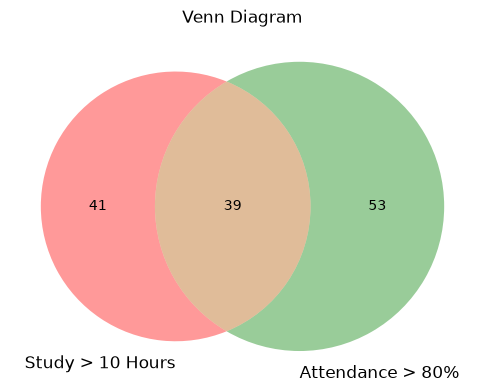

In [ ]:
# Create sets of student indices
study = set(df[df["study_hours"] > 10].index)
attendance = set(df[df["attendance"] > 80].index)

plt.figure(figsize=(6,6))
venn2([study, attendance], set_labels=("Study > 10 Hours", "Attendance > 80%"))

plt.title("Venn Diagram")
plt.show()

# 5. Contingency Table & Probability Calculations

A **contingency table** is used to summarize the relationship between two categorical variables.

Here,

- Rows → Group Discussion (Yes / No)
- Columns → Final Exam Result (Pass / Fail)

The contingency table helps calculate:

- Joint Probability
- Marginal Probability
- Conditional Probability

In [ ]:
contingency_table = pd.crosstab(df["group_discussion"], df["final_exam_pass"], normalize='index') 
contingency_table

final_exam_pass,Fail,Pass
group_discussion,,
No,0.530612,0.469388
Yes,0.568627,0.431373


## Joint Probability

The **joint probability** is the probability that two events occur together.

In this project,

- Student participates in group discussion.
- Student passes the final examination.

Formula

**P(A ∩ B) = Students satisfying both conditions / Total Students**

In [16]:
total_students = len(df)
joint_probability = len(df[(df["group_discussion"] == "Yes") & (df["final_exam_pass"] == "Pass")]) / total_students
print("Joint Probability =", round(joint_probability,3))

Joint Probability = 0.22


## Marginal Probability

Marginal probability is the probability of a single event occurring without considering any other event.

Formula

**P(A) = Number of favorable outcomes / Total observations**

Here,
Event A = Student passes the final examination.

In [17]:
marginal_probability = (df["final_exam_pass"] == "Pass").mean()
print("Marginal Probability =", round(marginal_probability,3))

Marginal Probability = 0.45


## Conditional Probability

Conditional probability is the probability of an event occurring given that another event has already occurred.

Formula

**P(A|B) = P(A ∩ B) / P(B)**

In this project,

- A = Student passes the examination
- B = Student participated in group discussion

In [18]:
conditional_probability = (len(df[(df["group_discussion"] == "Yes") & (df["final_exam_pass"] == "Pass")]) / len(df[df["group_discussion"] == "Yes"]))
print("Conditional Probability =", round(conditional_probability,3))

Conditional Probability = 0.431


# 6. Understanding Relationships

Conditional probability tells us how likely an event is after knowing that another event has already happened.

In this project,

P(Pass∣Group Discussion)

is **high**, students who participate in group discussions have a greater chance of passing the exam.

## Relationship Between Events

### Independent or Dependent?

Group discussion participation and passing the exam are **dependent events** because participating in discussions can improve understanding and increase the probability of passing.

# 7. Bayes' Theorem Application

Bayes' Theorem is used to calculate the probability of an event based on prior knowledge of related events.

formula

**P(A|B) = (P(B|A) * P(A)) / P(B)**

where

- P(A|B) = Probability of event A given event B
- P(B|A) = Probability of event B given event A
- P(A) = Prior probability of event A
- P(B) = Total probability of event B

In [ ]:
# Students with attendance greater than 80%
high_attendance = df["attendance"] > 80

# P(High Attendance | Pass)
P_H_given_P = (
    (high_attendance & (df["final_exam_pass"] == "Pass")).sum()
    /
    (df["final_exam_pass"] == "Pass").sum()
)

# P(High Attendance | Fail)
P_H_given_F = (
    (high_attendance & (df["final_exam_pass"] == "Fail")).sum()
    /
    (df["final_exam_pass"] == "Fail").sum()
)

# P(High Attendance)
P_H = high_attendance.mean()

print("P(High Attendance | Pass) =", round(P_H_given_P, 4))
print("P(High Attendance | Fail) =", round(P_H_given_F, 4))
print("P(High Attendance) =", round(P_H, 4))

P(High Attendance | Pass) = 0.5222
P(High Attendance | Fail) = 0.4091
P(High Attendance) = 0.46


## Given Information

Historical data shows:

- P(High Attendance | Pass) = 0.5222

- P(High Attendance | Fail) = 0.4091

- P(High Attendance) = 0.46

We need to calculate

**P(Pass | High Attendance)**

In [23]:
# Using Total Probability to calculate P(Pass)
P_pass = (P_H - P_H_given_F) / (P_H_given_P - P_H_given_F)
P_fail = 1 - P_pass

print("P(Pass) =", round(P_pass,4))
print("P(Fail) =", round(P_fail,4))

P(Pass) = 0.45
P(Fail) = 0.55


In [24]:
# Bayes' Theorem
P_pass_given_H = (P_H_given_P * P_pass) / P_H
print("P(Pass | High Attendance) =", round(P_pass_given_H,4))

P(Pass | High Attendance) = 0.5109


### Interpretation

The probability that a student **passed the final examination given that the student had high attendance (>80%)** is approximately **51.09%**.

This result indicates that although attendance is an important factor, **high attendance alone does not guarantee passing the examination**. Other factors such as **study hours, previous test scores, and participation in group discussions** also influence the final result.